In [ ]:
import pandas as pd

# --- Define your fine-tuned results ---
finetuned_data = {
    "Model": [
        "mxbai-embed-large-v1",
        "gte-large",
        "voyage-3",
        "gemini",
        "text-embedding-3-large",
    ],
    "arabic": [
        "0.84(0.82)/0.51(0.64)[0.73]",
        "0.82(0.79)/0.51(0.61)[0.71]",
        "0.84(0.82)/0.8(0.82)[0.7]",
        "0.83(0.81)/0.5(0.66)[0.69]",
        "0.89(0.89)/0.84(0.85)[0.73]",
    ],
    "german": [
        "0.85(0.83)/0.65(0.66)[0.74]",
        "0.81(0.81)/0.64(0.69)[0.72]",
        "0.83(0.81)/0.74(0.75)[0.7]",
        "0.85(0.84)/0.76(0.76)[0.69]",
        "0.88(0.89)/0.82(0.83)[0.75]",
    ],
    "hindi": [
        "0.83(0.82)/0.61(0.64)[0.74]",
        "0.83(0.81)/0.61(0.66)[0.72]",
        "0.84(0.82)/0.65(0.68)[0.75]",
        "0.84(0.81)/0.58(0.62)[0.69]",
        "0.89(0.89)/0.63(0.67)[0.8]",
    ],
    "portuguese": [
        "0.84(0.83)/0.53(0.66)[0.73]",
        "0.82(0.8)/0.52(0.67)[0.71]",
        "0.83(0.81)/0.74(0.79)[0.7]",
        "0.84(0.82)/0.69(0.73)[0.72]",
        "0.89(0.89)/0.85(0.86)[0.74]",
    ],
    "italian": [
        "0.84(0.82)/0.68(0.72)[0.73]",
        "0.82(0.8)/0.65(0.71)[0.71]",
        "0.83(0.82)/0.82(0.83)[0.7]",
        "0.85(0.83)/0.77(0.78)[0.69]",
        "0.88(0.89)/0.84(0.85)[0.87]",
    ],
    "spanish": [
        "0.84(0.82)/0.61(0.66)[0.73]",
        "0.82(0.8)/0.62(0.68)[0.71]",
        "0.84(0.82)/0.73(0.75)[0.71]",
        "0.85(0.83)/0.73(0.75)[0.72]",
        "0.89(0.88)/0.77(0.8)[0.74]",
    ],
    "french": [
        "0.84(0.83)/0.73(0.76)[0.73]",
        "0.82(0.81)/0.72(0.77)[0.72]",
        "0.83(0.82)/0.79(0.81)[0.7]",
        "0.85(0.84)/0.8(0.81)[0.69]",
        "0.89(0.89)/0.8(0.83)[0.73]",
    ],
}

# --- Convert to DataFrame ---
finetuned_df = pd.DataFrame(finetuned_data)

# --- Reshape to long format ---
finetuned_long = finetuned_df.melt(
    id_vars="Model", var_name="Dataset", value_name="Finetuned_Score"
)


# --- Parser: extract the five metrics ---
def parse_finetuned_cell(cell):
    """
    Parses a string of the form:
    '0.93(0.91)/0.75(0.81)[0.71]' into:
    Jigsaw_Macro, Jigsaw_True, Task_Macro, Task_True, Certified_Macro
    """
    try:
        jigsaw_part, rest = cell.split("/")
        jigsaw_macro = float(jigsaw_part.split("(")[0])
        jigsaw_true = float(jigsaw_part.split("(")[1].rstrip(")"))

        task_part, certified_part = rest.split("[")
        task_macro = float(task_part.split("(")[0])
        task_true = float(task_part.split("(")[1].rstrip(")"))

        certified_macro = float(certified_part.rstrip("]"))
        return pd.Series(
            [jigsaw_macro, jigsaw_true, task_macro, task_true, certified_macro]
        )
    except Exception as e:
        print(f"Error parsing cell: {cell} -> {e}")
        return pd.Series([None] * 5)


# --- Apply parsing function ---
finetuned_long[
    ["Jigsaw_Macro", "Jigsaw_True", "Task_Macro", "Task_True", "Certified_Macro"]
] = finetuned_long["Finetuned_Score"].apply(parse_finetuned_cell)

# --- Drop the raw string column ---
finetuned_long.drop(columns="Finetuned_Score", inplace=True)

# `finetuned_long` is now ready for analysis or plotting
finetuned_long.head()

,Model,Dataset,Jigsaw_Macro,Jigsaw_True,Task_Macro,Task_True,Certified_Macro
0,mxbai-embed-large-v1,arabic,0.84,0.82,0.51,0.64,0.73
1,gte-large,arabic,0.82,0.79,0.51,0.61,0.71
2,voyage-3,arabic,0.84,0.82,0.80,0.82,0.70
3,gemini,arabic,0.83,0.81,0.50,0.66,0.69
4,text-embedding-3-large,arabic,0.89,0.89,0.84,0.85,0.73


In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
import copy

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.plotting_style import set_figure_size


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


['arabic', 'german', 'hindi', 'portuguese', 'italian', 'spanish', 'french']


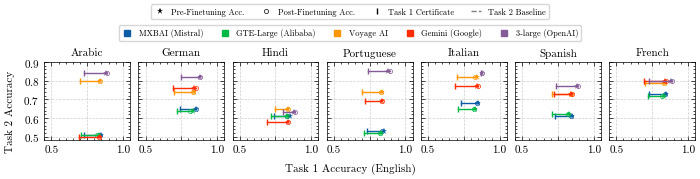

In [25]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

# Apply SciencePlots style
# plt.style.use(["science", "no-latex", "scatter"])

# Use the cleaned finetuned DataFrame
models = finetuned_long["Model"].unique()
datasets = list(finetuned_long["Dataset"].unique())  # order preserved
print(datasets)

titles = {
    "arabic": "Arabic",
    "english": "English",
    "spanish": "Spanish",
    "portuguese": "Portuguese",
    "german": "German",
    "hindi": "Hindi",
    "french": "French",
    "italian": "Italian",
}

# Provide Jigsaw baseline macro accuracy separately for plotting stars
baseline_jigsaw_macro = {
    "mxbai-embed-large-v1": 0.85,
    "gte-large": 0.83,
    "voyage-3": 0.84,
    "gemini": 0.84,
    "text-embedding-3-large": 0.88,
}

# Plot for each dataset
fig, axs = plt.subplots(
    1, len(datasets), sharey=True, layout="constrained", gridspec_kw={"hspace": 0.0}
)

for i, dataset in enumerate(datasets):
    ax = axs[i]

    # ax.axhline(min_baseline_macro, linestyle="--", color="gray", label="Min Baseline Acc. (Task 2)")

    for j, model in enumerate(models):
        color = f"C{j}"
        row = finetuned_long[
            (finetuned_long["Model"] == model) & (finetuned_long["Dataset"] == dataset)
        ]

        row = row.iloc[0]
        baseline_macro = baseline_jigsaw_macro[model]

        # Line connecting baseline, finetuned, certified
        x_vals = [baseline_macro, row["Jigsaw_Macro"], row["Certified_Macro"]]
        y_vals = [row["Task_Macro"]] * 3
        ax.plot(x_vals, y_vals, color=color, linestyle="-", marker="none")

        # Markers
        # ax.scatter(baseline_macro, row["Task_Macro"], color=color, marker="*", s=2)  # baseline
        # ax.scatter(row["Jigsaw_Macro"], row["Task_Macro"], color=color, facecolors="none", marker="o", s=2)  # finetuned
        # ax.scatter(row["Certified_Macro"], row["Task_Macro"], edgecolors=color, marker="o", s=2)  # certified
        ax.plot(
            row["Jigsaw_Macro"],
            row["Task_Macro"],
            color=color,
            marker="o",
            markersize=3,
            markeredgewidth=0.5,
            markerfacecolor="none",
        )  # finetuned
        ax.plot(
            baseline_macro,
            row["Task_Macro"],
            color=color,
            marker="*",
            markersize=5,
            markeredgewidth=0.0,
        )  # baseline
        ax.plot(
            row["Certified_Macro"],
            row["Task_Macro"],
            color=color,
            marker="|",
            markersize=5,
            # markerfacecolor="none",
            # markeredgewidth=0.5,
        )  # certified - hollow circle with thinner edge

    # Title and axes
    ax.set_title(titles[dataset], y=1.01, va="center", fontsize=8)
    ax.set_xlim(0.45, 1.05)
    ax.set_xticks([0.5, 0.75, 1.0], labels=["0.5", "", "1.0"])
    ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])
    # ax.set_ylim(0.55, 0.85)
    ax.grid(True, linestyle="--", alpha=0.6)

import matplotlib.lines as mlines

model_names = {
    "text-embedding-3-large": "3-large (OpenAI)",
    "mxbai-embed-large-v1": "MXBAI (Mistral)",
    "gemini": "Gemini (Google)",
    "gte-large": "GTE-Large (Alibaba)",
    "voyage-3": "Voyage AI",
}

# Top row: model-color legend (simplified labels)
model_lines = []
for j, model in enumerate(models):
    color = f"C{j}"
    # Create a legend entry for each model
    model_lines.append(
        mlines.Line2D(
            [0],
            [0],
            color=color,
            lw=0,
            marker="s",
            markersize=5,
            label=model_names[model],
        )
    )


# Bottom row: marker types and dashed line
symbol_lines = [
    mlines.Line2D(
        [0],
        [0],
        marker="*",
        lw=0,
        color="black",
        markersize=5,
        markeredgewidth=0.0,
        label="Pre-Finetuning Acc.",
    ),
    mlines.Line2D(
        [0],
        [0],
        marker="o",
        markersize=3,
        lw=0,
        color="black",
        markeredgewidth=0.5,
        markerfacecolor="none",
        label="Post-Finetuning Acc.",
    ),
    mlines.Line2D(
        [0],
        [0],
        marker="|",
        lw=0,
        color="black",
        markersize=5,
        label="Task 1 Certificate",
    ),
    mlines.Line2D([0], [0], linestyle="--", color="gray", label="Task 2 Baseline"),
]

# Combine both rows
full_legend = model_lines + symbol_lines

legend = fig.legend(
    handles=symbol_lines,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.15),  # position above the plot
    ncol=4,  # auto-wrap into two rows
    frameon=True,  # outline box
    handlelength=1.2,
    fontsize=6,
)

legend = fig.legend(
    handles=model_lines,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.99),  # position above the plot
    ncol=5,  # auto-wrap into two rows
    frameon=True,  # outline box
    fontsize=6,
    handlelength=1.2,
)

fig.supxlabel("Task 1 Accuracy (English)", fontsize=8)
fig.supylabel("Task 2 Accuracy", fontsize=8)

# Legend: only one color entry per model
# custom_lines = [plt.Line2D([0], [0], color=model_colors[m], lw=4) for m in models]
# ax.legend(custom_lines, models, title="Model", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)

set_figure_size(
    fig,
    fraction=1.0,
    subplots=(1, len(datasets)),
    dpi=300,
    shrink_height=1.1,
    portrait=True,
)
plt.savefig("figures/multilang.pdf", dpi=300)